In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
# Load the breast cancer dataset
cancer = load_breast_cancer()
# Create a DataFrame for the 30 numerical features
df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)

In [3]:
# Include the target column for reference (0 = Malignant, 1 = Benign)
df['target'] = cancer.target

print(f"Dataset loaded successfully. Shape: {df.shape}")
print(f"Features count: {len(cancer.feature_names)}")
df.head()

Dataset loaded successfully. Shape: (569, 31)
Features count: 30


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [9]:
# Drop the target column to prevent feature leakage
X = df.drop(columns=['target'])

In [10]:
# Standardize features to mean=0 and variance=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features separated and scaled successfully.")
print(f"Scaled data shape: {X_scaled.shape}")

Features separated and scaled successfully.
Scaled data shape: (569, 30)


In [11]:
# Track inertia values across multiple cluster counts
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

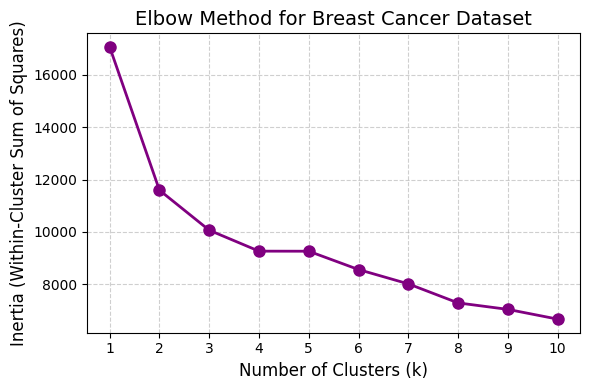

In [12]:
# Plot the Elbow Curve
plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o', linestyle='-', color='purple', linewidth=2, markersize=8)
plt.title("Elbow Method for Breast Cancer Dataset", fontsize=14)
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Inertia (Within-Cluster Sum of Squares)", fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [13]:
# Fit K-Means with 2 clusters (Malignant vs Benign)
optimal_k = 2
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [14]:
# Append the assigned clusters back to our main DataFrame
df['Cluster'] = cluster_labels

In [15]:
# Calculate Silhouette Score using the full 30D scaled feature matrix
sil_avg = silhouette_score(X_scaled, cluster_labels)
print(f"K-Means clustering complete for k = {optimal_k}.")
print(f"Average Silhouette Score (calculated on 30D scaled data): {sil_avg:.4f}")

K-Means clustering complete for k = 2.
Average Silhouette Score (calculated on 30D scaled data): 0.3447


In [26]:
# Reduce from 30 dimensions to 2 dimensions for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [27]:
# Store PCA dimensions in the dataframe
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

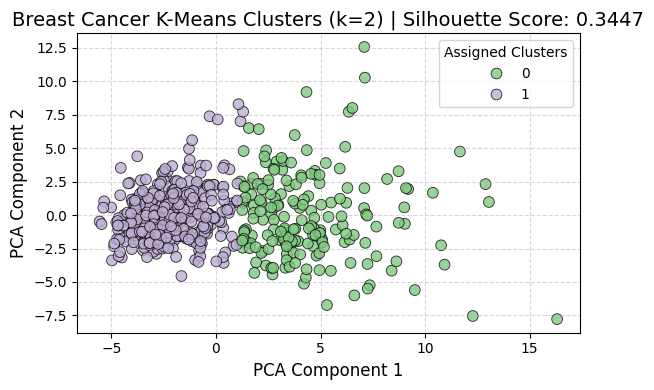

In [28]:
# Plot the final clusters in 2D space
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='PCA1', y='PCA2', hue='Cluster', data=df,
    palette='Accent', s=60, edgecolor='k', alpha=0.8
)
plt.title(f"Breast Cancer K-Means Clusters (k=2) | Silhouette Score: {sil_avg:.4f}", fontsize=14)
plt.xlabel("PCA Component 1", fontsize=12)
plt.ylabel("PCA Component 2", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Assigned Clusters")
plt.tight_layout()
plt.show()